In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.widgets import Slider

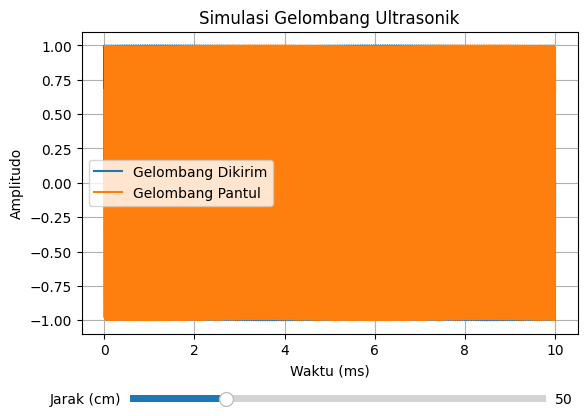

In [2]:
# Konstanta
v = 343  # kecepatan bunyi (m/s)
f = 40000  # frekuensi ultrasonik (Hz)

# Fungsi gelombang
def gelombang(t, delay):
    return np.sin(2 * np.pi * f * (t - delay))

# Waktu simulasi
t = np.linspace(0, 0.01, 5000)  # 10 ms

# Plot awal
fig, ax = plt.subplots()
plt.subplots_adjust(bottom=0.25)

jarak_awal = 50  # cm
d = jarak_awal / 100  # meter
delay = 2 * d / v

y_kirim = np.sin(2 * np.pi * f * t)
y_pantul = gelombang(t, delay)

line1, = ax.plot(t * 1000, y_kirim, label="Gelombang Dikirim")
line2, = ax.plot(t * 1000, y_pantul, label="Gelombang Pantul")

ax.set_xlabel("Waktu (ms)")
ax.set_ylabel("Amplitudo")
ax.set_title("Simulasi Gelombang Ultrasonik")
ax.legend()
ax.grid()

# Slider jarak
ax_slider = plt.axes([0.2, 0.1, 0.65, 0.03])
slider = Slider(ax_slider, "Jarak (cm)", 5, 200, valinit=jarak_awal)

# Update saat slider digeser
def update(val):
    d = slider.val / 100
    delay = 2 * d / v
    y_pantul = gelombang(t, delay)
    line2.set_ydata(y_pantul)
    
    waktu_ms = delay * 1000
    ax.set_title(f"Jarak = {slider.val:.1f} cm | Waktu Pantul = {waktu_ms:.2f} ms")
    fig.canvas.draw_idle()

slider.on_changed(update)

plt.show()